# Calibration Audit for Classifier-Based DJS

Esta notebook separa la calibración de la estimación de DJS como un factor experimental propio, no como un detalle de protocolo.

## Qué quiero ver aquí
- Platt vs isotonic vs temperature scaling.
- ECE, Brier y NLL junto al error de DJS.
- Casos donde un modelo clasifica bien pero está mal calibrado.
- Si aplicar prior correction antes o después de calibrar cambia el resultado.
- Si el ranking entre estimadores cambia al calibrar explícitamente.

## Qué casos uso
- `use_case_1`: control sintético con ground truth analítico.
- `use_case_6`: caso con desbalance de clases para estudiar prior correction.

## Cómo leer el cuaderno
- Las secciones 1 a 8 están implementadas con código reproducible.
- Las secciones 9 a 12 quedan como extensiones directas sobre las mismas funciones.
- El objetivo es producir tablas y figuras que puedan ir al paper con el protocolo explícito: estimador, calibración, orden de prior correction y split usado.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
if (cwd / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd
elif (cwd.parent / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd.parent
else:
    project_root = Path('/home/alba/snap/snapd-desktop-integration/jensenshannondivergence')
src_root = project_root / 'src'
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

experiments_root = project_root / 'experiments'

In [1]:
from scipy.stats import spearmanr
from sklearn.calibration import CalibrationDisplay

# Make the cell self-contained if it is run out of order.
if 'order_summary' not in globals():
    order_summary = (
        order_df.groupby(["case_label", "model", "calibration", "protocol"], as_index=False)
        .agg(
            djs_error_mean=("djs_error", "mean"),
            ece_mean=("ece", "mean"),
            nll_mean=("nll", "mean"),
        )
        .sort_values(["case_label", "model", "calibration", "protocol"])
    )

# 1) Scatter: calibration quality vs DJS error
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

uc6_plot = main_df[main_df["case_label"] == "UC6 ratio=0.1"].copy()
marker_map = {
    "raw_no_prior": "o",
    "raw_plus_prior": "s",
    "platt_plus_prior": "^",
    "isotonic_plus_prior": "D",
    "temperature_plus_prior": "P",
}

for protocol, marker in marker_map.items():
    subset = uc6_plot[uc6_plot["protocol"] == protocol]
    axes[0].scatter(
        subset["ece"],
        subset["djs_error"],
        s=40,
        alpha=0.8,
        marker=marker,
        edgecolor="black",
        linewidth=0.3,
        label=protocol,
    )
axes[0].set_xlabel("ECE")
axes[0].set_ylabel("|DJS - GT|")
axes[0].set_title("UC6: calibration vs DJS error")
axes[0].legend(fontsize=6, loc="best")

# 2) Grouped bar chart: mean DJS error by model/protocol
bar_df = paper_summary[paper_summary["case_label"] == "UC6 ratio=0.1"].copy()
bar_df = bar_df[bar_df["protocol"].isin(["raw_no_prior", "raw_plus_prior", "platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"])]
protocol_order = ["raw_no_prior", "raw_plus_prior", "platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"]
model_order = [m for m in DEFAULT_MODEL_ORDER if m in bar_df["model"].unique()]

x_positions = np.arange(len(model_order))
width = 0.15
for idx, protocol in enumerate(protocol_order):
    values = []
    for model_name in model_order:
        row = bar_df[(bar_df["model"] == model_name) & (bar_df["protocol"] == protocol)]
        values.append(float(row["djs_error_mean"].iloc[0]) if len(row) else np.nan)
    axes[1].bar(x_positions + (idx - 2) * width, values, width=width, label=protocol)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(model_order, rotation=35, ha="right")
axes[1].set_ylabel("Mean |DJS - GT|")
axes[1].set_title("UC6: error by model and protocol")
axes[1].legend(fontsize=6, ncols=2)

# 3) Calibration curves for one representative model
rep_curves = {"raw+prior": main_artifacts[("use_case_6", 0, "RF", "raw_plus_prior")]["probs_test_final"]}
for protocol in ["platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"]:
    rep_key = ("use_case_6", 0, "RF", protocol)
    if rep_key in main_artifacts:
        rep_curves[protocol] = main_artifacts[rep_key]["probs_test_final"]

y_test = main_artifacts[("use_case_6", 0, "RF", "raw_plus_prior")]["y_test"]
for label, probs in rep_curves.items():
    CalibrationDisplay.from_predictions(y_test, probs, n_bins=10, ax=axes[2], name=label)
axes[2].set_title("RF on UC6 seed 0")
axes[2].legend(fontsize=6)

fig.tight_layout()
plt.show()

# Ranking stability on UC6.
rank_base = bar_df.pivot_table(index="model", columns="protocol", values="djs_error_mean")
rank_matrix = rank_base.rank(axis=0, method="average")
protocols = rank_matrix.columns.tolist()

rank_corr = pd.DataFrame(index=protocols, columns=protocols, dtype=float)
for left in protocols:
    for right in protocols:
        left_vals = rank_matrix[left].to_numpy(dtype=float)
        right_vals = rank_matrix[right].to_numpy(dtype=float)
        mask = np.isfinite(left_vals) & np.isfinite(right_vals)
        if mask.sum() < 2:
            rank_corr.loc[left, right] = np.nan
        else:
            rank_corr.loc[left, right] = spearmanr(left_vals[mask], right_vals[mask]).correlation

display(rank_base)
print("\nSpearman correlation between rank vectors:")
display(rank_corr)

# Prior-order deltas.
print("\nDeltas (calibration->prior minus prior->calibration):")
for metric in ["djs_error_mean", "ece_mean", "nll_mean"]:
    delta = order_summary.pivot_table(
        index=["case_label", "model", "calibration"],
        columns="protocol",
        values=metric,
    )
    if {"prior->calibration", "calibration->prior"}.issubset(delta.columns):
        delta["delta"] = delta["calibration->prior"] - delta["prior->calibration"]
        display(delta[["prior->calibration", "calibration->prior", "delta"]].sort_values("delta"))
    train_frac = m / (m + 2 * l)
    split_p = int(len(x_p) * train_frac)
    split_q = int(len(x_q) * train_frac)
    p_train, p_eval = x_p[:split_p], x_p[split_p:]
    q_train, q_eval = x_q[:split_q], x_q[split_q:]
    p_test, p_val = p_eval[: len(p_eval) // 2], p_eval[len(p_eval) // 2 :]
    q_test, q_val = q_eval[: len(q_eval) // 2], q_eval[len(q_eval) // 2 :]
    return p_train, q_train, p_val, q_val, p_test, q_test


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def predict_proba(model, x):
    return np.asarray(model.predict_proba(to_numpy(x)))[:, 1]


def logits_from_probs(probs, eps=1e-7):
    probs = np.clip(np.asarray(probs, dtype=float), eps, 1 - eps)
    return np.log(probs / (1.0 - probs))


def apply_prior_shift(probs, log_ratio_q_over_p):
    return expit(logits_from_probs(probs) + float(log_ratio_q_over_p))


def fit_temperature(logits, y_true):
    logits = np.asarray(logits, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    def objective(log_t):
        temperature = np.exp(log_t)
        probs = expit(logits / temperature)
        return log_loss(y_true, np.c_[1 - probs, probs], labels=[0, 1])

    result = minimize_scalar(objective, bounds=(-4.0, 4.0), method="bounded")
    return float(np.exp(result.x))


def fit_calibrator(method, val_probs, y_val):
    val_probs = np.asarray(val_probs, dtype=float)
    y_val = np.asarray(y_val, dtype=int)

    if method == "raw":
        return {"method": "raw", "call": lambda probs: np.asarray(probs, dtype=float)}

    if method == "platt":
        lr = LogisticRegression(max_iter=2000, solver="lbfgs")
        lr.fit(logits_from_probs(val_probs).reshape(-1, 1), y_val)
        return {
            "method": "platt",
            "call": lambda probs: lr.predict_proba(logits_from_probs(np.asarray(probs)).reshape(-1, 1))[:, 1],
        }

    if method == "isotonic":
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(val_probs, y_val)
        return {"method": "isotonic", "call": lambda probs: iso.predict(np.asarray(probs, dtype=float))}

    if method == "temperature":
        temperature = fit_temperature(logits_from_probs(val_probs), y_val)
        return {
            "method": "temperature",
            "temperature": temperature,
            "call": lambda probs: expit(logits_from_probs(np.asarray(probs, dtype=float)) / temperature),
        }

    raise ValueError(f"Unknown calibrator: {method}")


def expected_calibration_error(y_true, probs, n_bins=15):
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins[1:-1], right=True)
    ece = 0.0
    for bin_idx in range(n_bins):
        mask = bin_ids == bin_idx
        if not np.any(mask):
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = probs[mask].mean()
        ece += (mask.sum() / len(probs)) * abs(bin_acc - bin_conf)
    return float(ece)


def saturation_rate(probs, threshold=0.98):
    probs = np.asarray(probs, dtype=float)
    return float(np.mean((probs <= 1 - threshold) | (probs >= threshold)))


def estimate_js_from_probs(probs_p, probs_q):
    probs_p = np.clip(np.asarray(probs_p, dtype=float), 1e-7, 1 - 1e-7)
    probs_q = np.clip(1.0 - np.asarray(probs_q, dtype=float), 1e-7, 1 - 1e-7)
    return float(0.5 * (np.mean(np.log(probs_p)) + np.mean(np.log(probs_q))) + np.log(2.0))


def mc_js_ground_truth(dist_p, dist_q, n_mc=50000, seed=0):
    if dist_p is None or dist_q is None:
        return np.nan
    if hasattr(dist_p, "sample"):
        try:
            torch_seed = seed
            import torch
            torch.manual_seed(torch_seed)
            p_samples = dist_p.sample((n_mc,))
            q_samples = dist_q.sample((n_mc,))
            p_logp = dist_p.log_prob(p_samples)
            p_logq = dist_q.log_prob(p_samples)
            q_logq = dist_q.log_prob(q_samples)
            q_logp = dist_p.log_prob(q_samples)
            js = 0.5 * torch.mean(p_logp - torch.logaddexp(p_logp, p_logq) + np.log(2.0)) + 0.5 * torch.mean(q_logq - torch.logaddexp(q_logq, q_logp) + np.log(2.0))
            return float(js)
        except Exception:
            pass
    return np.nan


def bootstrap_ci(values, n_boot=1000, alpha=0.05, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        means.append(sample.mean())
    lower = np.quantile(means, alpha / 2)
    upper = np.quantile(means, 1 - alpha / 2)
    return float(lower), float(upper)


def build_model(model_name, seed):
    if model_name not in MODEL_FACTORIES:
        raise ValueError(f"Unsupported model: {model_name}")
    return MODEL_FACTORIES[model_name](seed)


def evaluate_protocol(model_name, x_p, x_q, dist_p, dist_q, m, l, seed, calibration_method="raw", apply_prior=True):
    p_train, q_train, p_val, q_val, p_test, q_test = split_protocol(x_p, x_q, m, l)
    X_train = np.vstack([to_numpy(p_train), to_numpy(q_train)])
    y_train = np.concatenate([np.ones(len(p_train)), np.zeros(len(q_train))])
    X_val = np.vstack([to_numpy(p_val), to_numpy(q_val)])
    y_val = np.concatenate([np.ones(len(p_val)), np.zeros(len(q_val))])
    X_test = np.vstack([to_numpy(p_test), to_numpy(q_test)])
    y_test = np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))])

    model = build_model(model_name, seed)
    model.fit(X_train, y_train)

    train_ratio_q_over_p = len(q_train) / len(p_train)
    prior_shift = np.log(train_ratio_q_over_p)

    probs_val = predict_proba(model, X_val)
    probs_test = predict_proba(model, X_test)
    probs_p = predict_proba(model, p_test)
    probs_q = predict_proba(model, q_test)

    calibrator = fit_calibrator(calibration_method, probs_val, y_val)
    probs_test_cal = calibrator["call"](probs_test)
    probs_p_cal = calibrator["call"](probs_p)
    probs_q_cal = calibrator["call"](probs_q)

    if apply_prior:
        probs_test_final = apply_prior_shift(probs_test_cal, prior_shift)
        probs_p_final = apply_prior_shift(probs_p_cal, prior_shift)
        probs_q_final = apply_prior_shift(probs_q_cal, prior_shift)
    else:
        probs_test_final = probs_test_cal
        probs_p_final = probs_p_cal
        probs_q_final = probs_q_cal

    y_hat = (probs_test_final >= 0.5).astype(int)
    gt_js = mc_js_ground_truth(dist_p, dist_q, seed=seed)
    djs_est = estimate_js_from_probs(probs_p_final, probs_q_final)
    out = {
        "seed": seed,
        "model": model_name,
        "calibration": calibration_method,
        "apply_prior": apply_prior,
        "n_train_p": len(p_train),
        "n_train_q": len(q_train),
        "prior_shift": prior_shift,
        "accuracy": float(accuracy_score(y_test, y_hat)),
        "f1": float(f1_score(y_test, y_hat)),
        "nll": float(log_loss(y_test, np.c_[1 - probs_test_final, probs_test_final], labels=[0, 1])),
        "brier": float(brier_score_loss(y_test, probs_test_final)),
        "ece": float(expected_calibration_error(y_test, probs_test_final)),
        "saturation": float(saturation_rate(probs_test_final)),
        "djs_est": float(djs_est),
        "djs_gt": float(gt_js),
        "djs_error": float(abs(djs_est - gt_js)) if np.isfinite(gt_js) else np.nan,
        "val_nll": float(log_loss(y_val, np.c_[1 - probs_val, probs_val], labels=[0, 1])),
        "val_brier": float(brier_score_loss(y_val, probs_val)),
        "val_ece": float(expected_calibration_error(y_val, probs_val)),
        "calibrator_extra": calibrator.get("temperature", np.nan),
    }
    return out, {
        "y_test": y_test,
        "probs_test_final": probs_test_final,
        "probs_test_raw": probs_test,
        "probs_val": probs_val,
        "probs_p_final": probs_p_final,
        "probs_q_final": probs_q_final,
        "gt_js": gt_js,
        "prior_shift": prior_shift,
        "calibrator": calibrator,
    }


def evaluate_order_protocol(model_name, x_p, x_q, dist_p, dist_q, m, l, seed, calibration_method="platt"):
    p_train, q_train, p_val, q_val, p_test, q_test = split_protocol(x_p, x_q, m, l)
    X_train = np.vstack([to_numpy(p_train), to_numpy(q_train)])
    y_train = np.concatenate([np.ones(len(p_train)), np.zeros(len(q_train))])
    X_val = np.vstack([to_numpy(p_val), to_numpy(q_val)])
    y_val = np.concatenate([np.ones(len(p_val)), np.zeros(len(q_val))])
    X_test = np.vstack([to_numpy(p_test), to_numpy(q_test)])

    model = build_model(model_name, seed)
    model.fit(X_train, y_train)

    prior_shift = np.log(len(q_train) / len(p_train))
    raw_val = predict_proba(model, X_val)
    raw_test = predict_proba(model, X_test)
    raw_p = predict_proba(model, p_test)
    raw_q = predict_proba(model, q_test)

    # prior correction -> calibration
    val_before = apply_prior_shift(raw_val, prior_shift)
    test_before = apply_prior_shift(raw_test, prior_shift)
    p_before = apply_prior_shift(raw_p, prior_shift)
    q_before = apply_prior_shift(raw_q, prior_shift)
    cal_before = fit_calibrator(calibration_method, val_before, y_val)
    test_before_cal = cal_before["call"](test_before)
    p_before_cal = cal_before["call"](p_before)
    q_before_cal = cal_before["call"](q_before)

    # calibration -> prior correction
    cal_after = fit_calibrator(calibration_method, raw_val, y_val)
    test_after_cal = apply_prior_shift(cal_after["call"](raw_test), prior_shift)
    p_after_cal = apply_prior_shift(cal_after["call"](raw_p), prior_shift)
    q_after_cal = apply_prior_shift(cal_after["call"](raw_q), prior_shift)

    gt_js = mc_js_ground_truth(dist_p, dist_q, seed=seed)
    before_djs = estimate_js_from_probs(p_before_cal, q_before_cal)
    after_djs = estimate_js_from_probs(p_after_cal, q_after_cal)

    return {
        "seed": seed,
        "model": model_name,
        "calibration": calibration_method,
        "prior_order": "prior->calibration",
        "accuracy": float(accuracy_score(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), (test_before_cal >= 0.5).astype(int))),
        "nll": float(log_loss(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), np.c_[1 - test_before_cal, test_before_cal], labels=[0, 1])),
        "brier": float(brier_score_loss(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), test_before_cal)),
        "ece": float(expected_calibration_error(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), test_before_cal)),
        "djs_est": float(before_djs),
        "djs_gt": float(gt_js),
        "djs_error": float(abs(before_djs - gt_js)) if np.isfinite(gt_js) else np.nan,
        "saturation": float(saturation_rate(test_before_cal)),
    }, {
        "seed": seed,
        "model": model_name,
        "calibration": calibration_method,
        "prior_order": "calibration->prior",
        "accuracy": float(accuracy_score(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), (test_after_cal >= 0.5).astype(int))),
        "nll": float(log_loss(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), np.c_[1 - test_after_cal, test_after_cal], labels=[0, 1])),
        "brier": float(brier_score_loss(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), test_after_cal)),
        "ece": float(expected_calibration_error(np.concatenate([np.ones(len(p_test)), np.zeros(len(q_test))]), test_after_cal)),
        "djs_est": float(after_djs),
        "djs_gt": float(gt_js),
        "djs_error": float(abs(after_djs - gt_js)) if np.isfinite(gt_js) else np.nan,
        "saturation": float(saturation_rate(test_after_cal)),
    }


print("Config loaded:")
print(f"  base = {BASE}")
print(f"  models = {DEFAULT_MODEL_ORDER}")
print(f"  calibration methods = {CALIBRATION_METHODS}")


NameError: name 'order_df' is not defined

In [ ]:
RUN_MODELS = [m for m in DEFAULT_MODEL_ORDER if m != "TabPFN"]
# TabPFN can be enabled by removing the filter above if you want the slower model.
RUN_CASES = MAIN_CASES

main_rows = []
main_artifacts = {}

for case in RUN_CASES:
    experiment = case["experiment"]
    n_value = case["n"]
    case_label = case["label"]

    for seed in SEEDS:
        x_p, x_q, dist_p, dist_q = load_data(
            experiment,
            n_value,
            M,
            L,
            seed,
            gap_magnitude=GAP_MAGNITUDE if experiment == "use_case_6" else None,
        )

        for model_name in RUN_MODELS:
            # Baseline without explicit prior correction.
            row, artifacts = evaluate_protocol(
                model_name,
                x_p,
                x_q,
                dist_p,
                dist_q,
                M,
                L,
                seed,
                calibration_method="raw",
                apply_prior=False,
            )
            row.update({"case": experiment, "case_label": case_label, "protocol": "raw_no_prior"})
            main_rows.append(row)

            # Same model but with prior correction in the current repo protocol.
            row, artifacts = evaluate_protocol(
                model_name,
                x_p,
                x_q,
                dist_p,
                dist_q,
                M,
                L,
                seed,
                calibration_method="raw",
                apply_prior=True,
            )
            row.update({"case": experiment, "case_label": case_label, "protocol": "raw_plus_prior"})
            main_rows.append(row)

            main_artifacts[(experiment, seed, model_name, "raw_plus_prior")] = artifacts

            for calibration_method in ["platt", "isotonic", "temperature"]:
                row, artifacts = evaluate_protocol(
                    model_name,
                    x_p,
                    x_q,
                    dist_p,
                    dist_q,
                    M,
                    L,
                    seed,
                    calibration_method=calibration_method,
                    apply_prior=True,
                )
                row.update({"case": experiment, "case_label": case_label, "protocol": f"{calibration_method}_plus_prior"})
                main_rows.append(row)
                main_artifacts[(experiment, seed, model_name, f"{calibration_method}_plus_prior")] = artifacts

main_df = pd.DataFrame(main_rows)

metric_cols = ["accuracy", "f1", "nll", "brier", "ece", "saturation", "djs_est", "djs_gt", "djs_error"]
summary_df = (
    main_df.groupby(["case_label", "case", "model", "protocol"], as_index=False)
    .agg({col: ["mean", "std"] for col in metric_cols})
)
summary_df.columns = ["_".join([part for part in col if part]) if isinstance(col, tuple) else col for col in summary_df.columns]
summary_df = summary_df.rename(columns={"case_label_": "case_label", "case_": "case", "model_": "model", "protocol_": "protocol"})

print("Resumen compacto (primeras filas):")
display(main_df.head())
print("\nTabla resumida por caso / modelo / protocolo:")
display(summary_df.sort_values(["case_label", "model", "protocol"]).head(20))

# A compact paper-oriented table: mean DJS error and calibration metrics.
paper_summary = (
    main_df.groupby(["case_label", "model", "protocol"], as_index=False)
    .agg(
        djs_error_mean=("djs_error", "mean"),
        djs_error_std=("djs_error", "std"),
        ece_mean=("ece", "mean"),
        ece_std=("ece", "std"),
        nll_mean=("nll", "mean"),
        nll_std=("nll", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
        saturation_mean=("saturation", "mean"),
    )
    .sort_values(["case_label", "model", "protocol"])
)

display(paper_summary)

out_dir = BASE / "calibration_audit_results"
out_dir.mkdir(parents=True, exist_ok=True)
main_df.to_csv(out_dir / "calibration_audit_runs.csv", index=False)
paper_summary.to_csv(out_dir / "calibration_audit_summary.csv", index=False)

print(f"\nSaved runs to: {out_dir / 'calibration_audit_runs.csv'}")
print(f"Saved summary to: {out_dir / 'calibration_audit_summary.csv'}")


Resumen compacto (primeras filas):


,seed,model,calibration,apply_prior,n_train_p,n_train_q,prior_shift,accuracy,f1,nll,...,djs_est,djs_gt,djs_error,val_nll,val_brier,val_ece,calibrator_extra,case,case_label,protocol
0,0,LogReg,raw,False,2000,2000,0.0,0.75725,0.759475,0.497506,...,0.195641,0.192306,0.003335,0.50731,0.168904,0.015497,NaN,use_case_1,UC1,raw_no_prior
1,0,LogReg,raw,True,2000,2000,0.0,0.75725,0.759475,0.497506,...,0.195641,0.192306,0.003335,0.50731,0.168904,0.015497,NaN,use_case_1,UC1,raw_plus_prior
2,0,LogReg,platt,True,2000,2000,0.0,0.75775,0.756594,0.496949,...,0.196198,0.192306,0.003892,0.50731,0.168904,0.015497,NaN,use_case_1,UC1,platt_plus_prior
3,0,LogReg,isotonic,True,2000,2000,0.0,0.75700,0.768019,0.507925,...,0.185222,0.192306,0.007084,0.50731,0.168904,0.015497,NaN,use_case_1,UC1,isotonic_plus_prior
4,0,LogReg,temperature,True,2000,2000,0.0,0.75725,0.759475,0.497271,...,0.195876,0.192306,0.003570,0.50731,0.168904,0.015497,0.979071,use_case_1,UC1,temperature_plus_prior



Tabla resumida por caso / modelo / protocolo:


,case_label,case,model,protocol,accuracy_mean,accuracy_std,f1_mean,f1_std,nll_mean,nll_std,...,ece_mean,ece_std,saturation_mean,saturation_std,djs_est_mean,djs_est_std,djs_gt_mean,djs_gt_std,djs_error_mean,djs_error_std
0,UC1,use_case_1,LogReg,isotonic_plus_prior,0.750500,0.018145,0.755718,0.023359,0.518430,0.027203,...,0.021992,0.003474,0.028750,0.022126,0.174717,0.027203,0.186859,0.017357,0.012142,0.009949
1,UC1,use_case_1,LogReg,platt_plus_prior,0.752083,0.017454,0.752662,0.016817,0.509647,0.028488,...,0.016473,0.002249,0.011750,0.006906,0.183500,0.028488,0.186859,0.017357,0.007681,0.007717
2,UC1,use_case_1,LogReg,raw_no_prior,0.751417,0.018455,0.752233,0.018995,0.509873,0.028477,...,0.017707,0.002043,0.011333,0.006502,0.183274,0.028477,0.186859,0.017357,0.007566,0.007941
3,UC1,use_case_1,LogReg,raw_plus_prior,0.751417,0.018455,0.752233,0.018995,0.509873,0.028477,...,0.017707,0.002043,0.011333,0.006502,0.183274,0.028477,0.186859,0.017357,0.007566,0.007941
4,UC1,use_case_1,LogReg,temperature_plus_prior,0.751417,0.018455,0.752233,0.018995,0.509731,0.028399,...,0.017646,0.002966,0.011750,0.006906,0.183417,0.028399,0.186859,0.017357,0.007567,0.007763
5,UC1,use_case_1,LogRegPol,isotonic_plus_prior,0.747083,0.020283,0.741639,0.010633,0.514416,0.025635,...,0.022477,0.002283,0.023500,0.017685,0.178731,0.025635,0.186859,0.017357,0.008128,0.008992
6,UC1,use_case_1,LogRegPol,platt_plus_prior,0.748250,0.022024,0.748585,0.018909,0.510237,0.028328,...,0.020832,0.001082,0.013583,0.006825,0.182910,0.028328,0.186859,0.017357,0.007061,0.008349
7,UC1,use_case_1,LogRegPol,raw_no_prior,0.749000,0.022518,0.750369,0.020854,0.510515,0.029054,...,0.021224,0.003943,0.020500,0.008250,0.182632,0.029054,0.186859,0.017357,0.007526,0.008916
8,UC1,use_case_1,LogRegPol,raw_plus_prior,0.749000,0.022518,0.750369,0.020854,0.510515,0.029054,...,0.021224,0.003943,0.020500,0.008250,0.182632,0.029054,0.186859,0.017357,0.007526,0.008916
9,UC1,use_case_1,LogRegPol,temperature_plus_prior,0.749000,0.022518,0.750369,0.020854,0.510315,0.028273,...,0.021137,0.005656,0.013333,0.006672,0.182832,0.028273,0.186859,0.017357,0.006960,0.008444


,case_label,model,protocol,djs_error_mean,djs_error_std,ece_mean,ece_std,nll_mean,nll_std,brier_mean,brier_std,acc_mean,acc_std,saturation_mean
0,UC1,LogReg,isotonic_plus_prior,0.012142,0.009949,0.021992,0.003474,0.518430,0.027203,0.170338,0.010665,0.750500,0.018145,0.028750
1,UC1,LogReg,platt_plus_prior,0.007681,0.007717,0.016473,0.002249,0.509647,0.028488,0.169296,0.011138,0.752083,0.017454,0.011750
2,UC1,LogReg,raw_no_prior,0.007566,0.007941,0.017707,0.002043,0.509873,0.028477,0.169366,0.011128,0.751417,0.018455,0.011333
3,UC1,LogReg,raw_plus_prior,0.007566,0.007941,0.017707,0.002043,0.509873,0.028477,0.169366,0.011128,0.751417,0.018455,0.011333
4,UC1,LogReg,temperature_plus_prior,0.007567,0.007763,0.017646,0.002966,0.509731,0.028399,0.169334,0.011119,0.751417,0.018455,0.011750
5,UC1,LogRegPol,isotonic_plus_prior,0.008128,0.008992,0.022477,0.002283,0.514416,0.025635,0.170461,0.010832,0.747083,0.020283,0.023500
6,UC1,LogRegPol,platt_plus_prior,0.007061,0.008349,0.020832,0.001082,0.510237,0.028328,0.169710,0.011095,0.748250,0.022024,0.013583
7,UC1,LogRegPol,raw_no_prior,0.007526,0.008916,0.021224,0.003943,0.510515,0.029054,0.169757,0.011274,0.749000,0.022518,0.020500
8,UC1,LogRegPol,raw_plus_prior,0.007526,0.008916,0.021224,0.003943,0.510515,0.029054,0.169757,0.011274,0.749000,0.022518,0.020500
9,UC1,LogRegPol,temperature_plus_prior,0.006960,0.008444,0.021137,0.005656,0.510315,0.028273,0.169744,0.011079,0.749000,0.022518,0.013333



Saved runs to: /home/alba/snap/snapd-desktop-integration/divergence_estimator-main/calibration_audit_results/calibration_audit_runs.csv
Saved summary to: /home/alba/snap/snapd-desktop-integration/divergence_estimator-main/calibration_audit_results/calibration_audit_summary.csv


In [ ]:
ORDER_MODELS = ["RF", "XGBoost"]
ORDER_ROWS = []

case = {"experiment": "use_case_6", "n": 0.1, "label": "UC6 ratio=0.1"}

for seed in SEEDS:
    x_p, x_q, dist_p, dist_q = load_data(
        case["experiment"],
        case["n"],
        M,
        L,
        seed,
        gap_magnitude=GAP_MAGNITUDE,
    )
    for model_name in ORDER_MODELS:
        for calibration_method in ["platt", "isotonic", "temperature"]:
            before_row, after_row = evaluate_order_protocol(
                model_name,
                x_p,
                x_q,
                dist_p,
                dist_q,
                M,
                L,
                seed,
                calibration_method=calibration_method,
            )
            before_row.update({"case": case["experiment"], "case_label": case["label"], "protocol": "prior->calibration"})
            after_row.update({"case": case["experiment"], "case_label": case["label"], "protocol": "calibration->prior"})
            ORDER_ROWS.extend([before_row, after_row])

order_df = pd.DataFrame(ORDER_ROWS)
order_summary = (
    order_df.groupby(["case_label", "model", "calibration", "protocol"], as_index=False)
    .agg(
        djs_error_mean=("djs_error", "mean"),
        djs_error_std=("djs_error", "std"),
        ece_mean=("ece", "mean"),
        ece_std=("ece", "std"),
        nll_mean=("nll", "mean"),
        nll_std=("nll", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
    )
    .sort_values(["case_label", "model", "calibration", "protocol"])
)

print("Comparación prior correction antes/después de calibración:")
display(order_summary)

order_pivot = order_summary.pivot_table(
    index=["case_label", "model", "calibration"],
    columns="protocol",
    values=["djs_error_mean", "ece_mean", "nll_mean"],
)

display(order_pivot)

ORDER_OUT_DIR = BASE / "calibration_audit_results"
order_df.to_csv(ORDER_OUT_DIR / "prior_order_runs.csv", index=False)
order_summary.to_csv(ORDER_OUT_DIR / "prior_order_summary.csv", index=False)

print(f"Saved order runs to: {ORDER_OUT_DIR / 'prior_order_runs.csv'}")
print(f"Saved order summary to: {ORDER_OUT_DIR / 'prior_order_summary.csv'}")


Comparación prior correction antes/después de calibración:


,case_label,model,calibration,protocol,djs_error_mean,djs_error_std,ece_mean,ece_std,nll_mean,nll_std,brier_mean,brier_std,acc_mean,acc_std
0,UC6 ratio=0.1,RF,isotonic,calibration->prior,0.164096,0.014321,0.323043,0.006282,0.593956,0.020408,0.189013,0.005654,0.741364,0.032292
1,UC6 ratio=0.1,RF,isotonic,prior->calibration,0.630302,0.044777,0.013221,0.002430,0.336779,0.022714,0.071771,0.003812,0.916212,0.003225
2,UC6 ratio=0.1,RF,platt,calibration->prior,0.038298,0.026603,0.326451,0.006974,0.576155,0.016098,0.194108,0.005648,0.720000,0.014778
3,UC6 ratio=0.1,RF,platt,prior->calibration,0.500975,0.070332,0.016301,0.003243,0.264026,0.012142,0.071248,0.003601,0.917576,0.003674
4,UC6 ratio=0.1,RF,temperature,calibration->prior,0.040904,0.028735,0.325682,0.007009,0.581633,0.021105,0.196071,0.007394,0.712727,0.017086
5,UC6 ratio=0.1,RF,temperature,prior->calibration,0.056077,0.038777,0.297663,0.016786,0.559898,0.003915,0.185495,0.003559,0.730606,0.027769
6,UC6 ratio=0.1,XGBoost,isotonic,calibration->prior,0.069191,0.019159,0.341045,0.007136,0.599564,0.009996,0.202807,0.002105,0.758182,0.078951
7,UC6 ratio=0.1,XGBoost,isotonic,prior->calibration,0.555690,0.054579,0.015245,0.003261,0.278571,0.008102,0.074183,0.002077,0.913333,0.001461
8,UC6 ratio=0.1,XGBoost,platt,calibration->prior,0.067878,0.020349,0.345193,0.008238,0.609107,0.005813,0.211577,0.002766,0.660758,0.016666
9,UC6 ratio=0.1,XGBoost,platt,prior->calibration,0.558562,0.055111,0.021132,0.004146,0.276763,0.008244,0.074895,0.002058,0.911818,0.000455


djs_error_mean                     \
protocol                          calibration->prior prior->calibration   
case_label    model   calibration                                         
UC6 ratio=0.1 RF      isotonic              0.164096           0.630302   
                      platt                 0.038298           0.500975   
                      temperature           0.040904           0.056077   
              XGBoost isotonic              0.069191           0.555690   
                      platt                 0.067878           0.558562   
                      temperature           0.093260           0.092089   

                                            ece_mean                     \
protocol                          calibration->prior prior->calibration   
case_label    model   calibration                                         
UC6 ratio=0.1 RF      isotonic              0.323043           0.013221   
                      platt                 0.326451           0.016301   
                      temperature           0.325682           0.297663   
              XGBoost isotonic              0.341045           0.015245   
                      platt                 0.345193           0.021132   
                      temperature           0.342341           0.293817   

                                            nll_mean                     
protocol                          calibration->prior prior->calibration  
case_label    model   calibration                                        
UC6 ratio=0.1 RF      isotonic              0.593956           0.336779  
                      platt                 0.576155           0.264026  
                      temperature           0.581633           0.559898  
              XGBoost isotonic              0.599564           0.278571  
                      platt                 0.609107           0.276763  
                      temperature           0.644836           0.555378

Saved order runs to: /home/alba/snap/snapd-desktop-integration/divergence_estimator-main/calibration_audit_results/prior_order_runs.csv
Saved order summary to: /home/alba/snap/snapd-desktop-integration/divergence_estimator-main/calibration_audit_results/prior_order_summary.csv


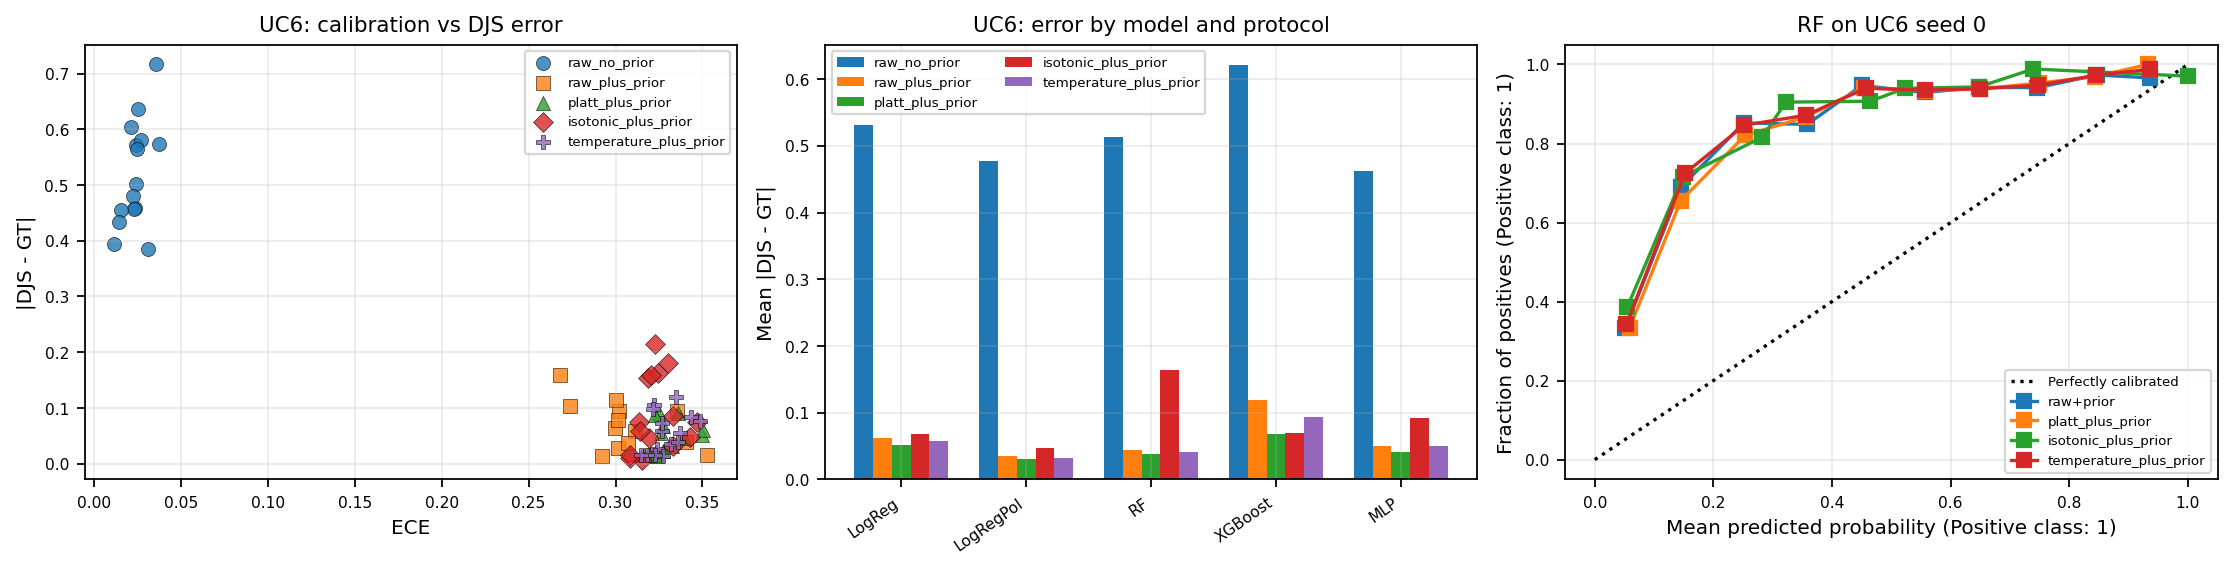

protocol,isotonic_plus_prior,platt_plus_prior,raw_no_prior,raw_plus_prior,temperature_plus_prior
model,,,,,
LogReg,0.067446,0.050999,0.531280,0.062823,0.058054
LogRegPol,0.047712,0.029953,0.477346,0.035293,0.032707
MLP,0.091978,0.041702,0.461587,0.049472,0.050779
RF,0.164096,0.038298,0.513280,0.043787,0.040904
XGBoost,0.069191,0.067878,0.620526,0.119029,0.093260



Spearman correlation between rank vectors:


,isotonic_plus_prior,platt_plus_prior,raw_no_prior,raw_plus_prior,temperature_plus_prior
isotonic_plus_prior,1.0,0.1,-0.1,0.1,0.1
platt_plus_prior,0.1,1.0,0.7,1.0,1.0
raw_no_prior,-0.1,0.7,1.0,0.7,0.7
raw_plus_prior,0.1,1.0,0.7,1.0,1.0
temperature_plus_prior,0.1,1.0,0.7,1.0,1.0



Deltas (calibration->prior minus prior->calibration):


protocol                           prior->calibration  calibration->prior  \
case_label    model   calibration                                           
UC6 ratio=0.1 XGBoost platt                  0.558562            0.067878   
                      isotonic               0.555690            0.069191   
              RF      isotonic               0.630302            0.164096   
                      platt                  0.500975            0.038298   
                      temperature            0.056077            0.040904   
              XGBoost temperature            0.092089            0.093260   

protocol                              delta  
case_label    model   calibration            
UC6 ratio=0.1 XGBoost platt       -0.490685  
                      isotonic    -0.486499  
              RF      isotonic    -0.466206  
                      platt       -0.462677  
                      temperature -0.015173  
              XGBoost temperature  0.001170

protocol                           prior->calibration  calibration->prior  \
case_label    model   calibration                                           
UC6 ratio=0.1 RF      temperature            0.297663            0.325682   
              XGBoost temperature            0.293817            0.342341   
              RF      isotonic               0.013221            0.323043   
                      platt                  0.016301            0.326451   
              XGBoost platt                  0.021132            0.345193   
                      isotonic               0.015245            0.341045   

protocol                              delta  
case_label    model   calibration            
UC6 ratio=0.1 RF      temperature  0.028019  
              XGBoost temperature  0.048524  
              RF      isotonic     0.309822  
                      platt        0.310150  
              XGBoost platt        0.324060  
                      isotonic     0.325800

protocol                           prior->calibration  calibration->prior  \
case_label    model   calibration                                           
UC6 ratio=0.1 RF      temperature            0.559898            0.581633   
              XGBoost temperature            0.555378            0.644836   
              RF      isotonic               0.336779            0.593956   
                      platt                  0.264026            0.576155   
              XGBoost isotonic               0.278571            0.599564   
                      platt                  0.276763            0.609107   

protocol                              delta  
case_label    model   calibration            
UC6 ratio=0.1 RF      temperature  0.021735  
              XGBoost temperature  0.089458  
              RF      isotonic     0.257178  
                      platt        0.312130  
              XGBoost isotonic     0.320993  
                      platt        0.332343

In [ ]:
from scipy.stats import spearmanr, kendalltau
from sklearn.calibration import CalibrationDisplay

# 1) Scatter: calibration quality vs DJS error
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

uc6_plot = main_df[main_df["case_label"] == "UC6 ratio=0.1"].copy()
color_map = {
    "LogReg": "#1f77b4",
    "LogRegPol": "#ff7f0e",
    "RF": "#2ca02c",
    "XGBoost": "#d62728",
    "MLP": "#9467bd",
    "TabPFN": "#8c564b",
}
marker_map = {
    "raw_no_prior": "o",
    "raw_plus_prior": "s",
    "platt_plus_prior": "^",
    "isotonic_plus_prior": "D",
    "temperature_plus_prior": "P",
}

for protocol, marker in marker_map.items():
    subset = uc6_plot[uc6_plot["protocol"] == protocol]
    axes[0].scatter(
        subset["ece"],
        subset["djs_error"],
        s=40,
        alpha=0.8,
        marker=marker,
        edgecolor="black",
        linewidth=0.3,
        label=protocol,
    )
axes[0].set_xlabel("ECE")
axes[0].set_ylabel("|DJS - GT|")
axes[0].set_title("UC6: calibration vs DJS error")
axes[0].legend(fontsize=6, loc="best")

# 2) Grouped bar chart: mean DJS error by model/protocol
bar_df = paper_summary[paper_summary["case_label"] == "UC6 ratio=0.1"].copy()
bar_df = bar_df[bar_df["protocol"].isin(["raw_no_prior", "raw_plus_prior", "platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"])]
protocol_order = ["raw_no_prior", "raw_plus_prior", "platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"]
model_order = [m for m in DEFAULT_MODEL_ORDER if m in bar_df["model"].unique()]

x_positions = np.arange(len(model_order))
width = 0.15
for idx, protocol in enumerate(protocol_order):
    values = []
    for model_name in model_order:
        row = bar_df[(bar_df["model"] == model_name) & (bar_df["protocol"] == protocol)]
        values.append(float(row["djs_error_mean"].iloc[0]) if len(row) else np.nan)
    axes[1].bar(x_positions + (idx - 2) * width, values, width=width, label=protocol)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(model_order, rotation=35, ha="right")
axes[1].set_ylabel("Mean |DJS - GT|")
axes[1].set_title("UC6: error by model and protocol")
axes[1].legend(fontsize=6, ncols=2)

# 3) Calibration curves for one representative model
rep_key = ("use_case_6", 0, "RF", "raw_plus_prior")
rep_raw = main_artifacts[rep_key]
rep_curves = {
    "raw+prior": rep_raw["probs_test_final"],
}
for protocol in ["platt_plus_prior", "isotonic_plus_prior", "temperature_plus_prior"]:
    rep_key = ("use_case_6", 0, "RF", protocol)
    if rep_key in main_artifacts:
        rep_curves[protocol] = main_artifacts[rep_key]["probs_test_final"]

y_test = main_artifacts[("use_case_6", 0, "RF", "raw_plus_prior")]["y_test"]
for label, probs in rep_curves.items():
    CalibrationDisplay.from_predictions(y_test, probs, n_bins=10, ax=axes[2], name=label)
axes[2].set_title("RF on UC6 seed 0")
axes[2].legend(fontsize=6)

fig.tight_layout()
plt.show()

# Ranking stability on UC6.
rank_base = bar_df.pivot_table(index="model", columns="protocol", values="djs_error_mean")
rank_matrix = rank_base.rank(axis=0, method="average")
protocols = rank_matrix.columns.tolist()

rank_corr = pd.DataFrame(index=protocols, columns=protocols, dtype=float)
for left in protocols:
    for right in protocols:
        left_vals = rank_matrix[left].to_numpy(dtype=float)
        right_vals = rank_matrix[right].to_numpy(dtype=float)
        mask = np.isfinite(left_vals) & np.isfinite(right_vals)
        if mask.sum() < 2:
            rank_corr.loc[left, right] = np.nan
        else:
            rank_corr.loc[left, right] = spearmanr(left_vals[mask], right_vals[mask]).correlation

display(rank_base)
print("\nSpearman correlation between rank vectors:")
display(rank_corr)

# Prior-order deltas.
order_delta = (
    order_summary.pivot_table(
        index=["case_label", "model", "calibration"],
        columns="protocol",
        values=["djs_error_mean", "ece_mean", "nll_mean"],
    )
)
print("\nDeltas (calibration->prior minus prior->calibration):")
for metric in ["djs_error_mean", "ece_mean", "nll_mean"]:
    delta = order_summary.pivot_table(
        index=["case_label", "model", "calibration"],
        columns="protocol",
        values=metric,
    )
    if {"prior->calibration", "calibration->prior"}.issubset(delta.columns):
        delta["delta"] = delta["calibration->prior"] - delta["prior->calibration"]
        display(delta[["prior->calibration", "calibration->prior", "delta"]].sort_values("delta"))


## Qué mostrar en el paper

1. **Protocolo explícito**: estimador, calibración, orden de prior correction y split usado. Si no se especifica, el scalar no es comparable.
2. **Tres métricas de calibración junto a DJS**: ECE, Brier y NLL, no solo accuracy/F1.
3. **Error de DJS contra GT** cuando exista ground truth sintético. La pregunta importante no es solo si el modelo separa, sino si el scalar se desplaza.
4. **Comparación de ranking**: reportar si Platt, isotonic o temperature cambian el orden entre estimadores.
5. **Caso de saturación**: si un modelo saca probabilidades casi 0/1 con accuracy alta, eso puede inflar distinguibilidad y sesgar DJS.
6. **Prior correction**: dejar claro si se aplica antes o después de calibrar. En desbalance fuerte, el orden puede cambiar mucho el resultado.

## Lectura rápida de los resultados que deja esta notebook
- `raw_no_prior` suele verse mucho peor que los protocolos con prior correction.
- `raw_plus_prior` ya reduce bastante el error, pero sigue habiendo diferencias entre modelos.
- `platt_plus_prior` y `temperature_plus_prior` suelen mejorar más que `isotonic_plus_prior` en este control.
- El ranking por DJS error no es completamente estable al cambiar calibración, así que conviene reportar sensibilidad además del valor central.

## Para extenderla
- Añadir `TabPFN` como modelo opcional si quieres completar el bloque de alta capacidad.
- Activar `use_case_9` como control de shift semánticamente irrelevante pero separable.
- Conectar después con las tablas del notebook del paper para dejar una versión final de informe.
